In [1]:
import pandas as pd
from pathlib import Path
import pyarrow.parquet as pq
from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np

#from sklearn.svm import OneClassSVM
from sklearn.preprocessing import MinMaxScaler
#from sklearn.model_selection import train_test_split
#from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from sklearn.manifold import TSNE

# Extracting and Preparing Data

In [2]:
dataset_root = Path(r"./dataset") # Raw string works without escaping \


@dataclass
class Case():
    info: pd.DataFrame
    measurements: pd.DataFrame


class RawDataset():

    def __init__(self, root, unit = "VG4", load_training=False, load_synthetic=False) -> None:
        
        
        read_pq_file = lambda f: pq.read_table(root / f).to_pandas()
        
        
        cases = {
            "test": [f"{unit}_generator_data_testing_real_measurements.parquet", root / f"{unit}_generator_data_testing_real_info.csv" ], 
        }
        
        if load_training:
            cases = {
                **cases,
                "train": [f"{unit}_generator_data_training_measurements.parquet", root / f"{unit}_generator_data_training_info.csv" ], 
            }
        
        if load_synthetic:
            cases = {
                **cases,
                "test_s01": [f"{unit}_generator_data_testing_synthetic_01_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_01_info.csv"], 
                "test_s02": [f"{unit}_generator_data_testing_synthetic_02_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_02_info.csv"]
            }
        
        
        self.data_dict = dict()
        
        for id_c, c in cases.items():
            # if you need to verify the parquet header:
            # pq_rows = RawDataset.read_parquet_schema_df(root / c[0])
            info = pd.read_csv(c[1])
            measurements = read_pq_file(c[0])
            self.data_dict[id_c] = Case(info, measurements)
            
        
        
    @staticmethod
    def read_parquet_schema_df(uri: str) -> pd.DataFrame:
        """Return a Pandas dataframe corresponding to the schema of a local URI of a parquet file.

        The returned dataframe has the columns: column, pa_dtype
        """
        # Ref: https://stackoverflow.com/a/64288036/
        schema = pq.read_schema(uri, memory_map=True)
        schema = pd.DataFrame(({"column": name, "pa_dtype": str(pa_dtype)} for name, pa_dtype in zip(schema.names, schema.types)))
        schema = schema.reindex(columns=["column", "pa_dtype"], fill_value=pd.NA)  # Ensures columns in case the parquet file has an empty dataframe.
        return schema

## Splitting the dataset

In [3]:
# Define Operating Modes
Operating_modes_name = [
    "turbine_mode", "equilibrium_turbine_mode", "pump_mode", "equilibrium_pump_mode",
    "short_circuit_mode", "equilibrium_short_circuit_mode", "machine_on", "machine_off", 
    "dyn_only_on", "all"
]

# Time Series Extraction Functions
def extracting_name_groups_time_series(rds, set_type):
    df_name_control_sensors = rds.data_dict[set_type].info
    control_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == True) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    sensors_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == False) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    return control_time_series_name["attribute_name"], sensors_time_series_name["attribute_name"]

def extracting_groups_time_series(rds, set_type):
    control_time_series_name, sensors_time_series_name = extracting_name_groups_time_series(rds, set_type=set_type)
    control_df = rds.data_dict[set_type].measurements[control_time_series_name]
    sensors_df = rds.data_dict[set_type].measurements[sensors_time_series_name]
    operating_modes_df = rds.data_dict[set_type].measurements[Operating_modes_name]
    return control_df, sensors_df, operating_modes_df

def get_indexes_operating_mode(operating_modes_df, operating_conditions):
    mask = pd.Series([True] * len(operating_modes_df), index=operating_modes_df.index)
    for column, value in operating_conditions.items():
        mask &= (operating_modes_df[column] == value)
    return operating_modes_df[mask].index

# Helper functions for feature extraction 
def feature_extraction(df, feature_prefixes, new_feature_name):
    feature_columns = df.columns[df.columns.str.startswith(tuple(feature_prefixes))]
    df[new_feature_name] = df[feature_columns].sum(axis=1)
    df.drop(columns=feature_columns, inplace=True)
    return df

# Helper functions for normalization
def normalize_features(df,scaler, fit = True):
    numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
    df[numerical_columns] = scaler.fit_transform(df[numerical_columns]) if fit else scaler.transform(df[numerical_columns])
    return df

def dynamic_group_features(df):
    feature_groups = {
        'voltage_current': df.columns[df.columns.str.startswith(("exc", "ph", "elec", "mid", "neutral"))].tolist(),
        'stator_temperature': df.columns[df.columns.str.startswith("stat_") & 
                                         df.columns.str.contains("coil|magn")].tolist(),
        'cooling_system': df.columns[df.columns.str.startswith("air_circ_")].tolist(),
        'heat_exchanger': df.columns[df.columns.str.startswith("water_circ_")].tolist()
    }

    # Flatten the list of all grouped features
    grouped_features = [feature for group in feature_groups.values() for feature in group]
    # Find complementary features
    complementary_features = [col for col in df.columns if col not in grouped_features]
    
    feature_groups['complementary'] = complementary_features

    return feature_groups

def preprocess_hydraulic_data(rds, set_type, operating_conditions, scaler, fit):
    """
    Preprocess the hydraulic site data to return normalized control and sensor signals filtered by operating conditions.

    Parameters:
    - rds: RawDataset object containing the data dictionary
    - set_type: Type of dataset to use ('train', 'test', etc.)
    - feature_group: The group of sensor features to select for preprocessing
    - operating_conditions: A dictionary specifying operating conditions to filter the data
    
    Returns:
    - Dictionary with two normalized and filtered DataFrames: control signals and sensor signals
    """
    # Step 1: Extract control, sensor, and operating mode time series
    control_df, sensors_df, operating_modes_df = extracting_groups_time_series(rds, set_type=set_type)

    # Step 2: Filter based on operating conditions if specified
    if operating_conditions:
        indexes = get_indexes_operating_mode(operating_modes_df, operating_conditions)
        control_df = control_df.loc[indexes]
        sensors_df = sensors_df.loc[indexes]
        
    # Select features containing both 'water' and 'opening' in their name
    water_opening_features = [col for col in control_df.columns if "water" in col and "opening" in col]
    control_df = feature_extraction(control_df, water_opening_features, "water_opening_sum")

    # Select features containing both 'injector' and 'opening' in their name
    injector_opening_features = [col for col in control_df.columns if "injector" in col and "opening" in col]
    control_df = feature_extraction(control_df, injector_opening_features, "injector_opening_sum")

    # Step 4 : Extract the groups of interest
    grouped_data = dynamic_group_features(sensors_df)
    selected_sensor_data = []
    for key in grouped_data.keys():
        selected_sensor_data.append(sensors_df[grouped_data[key]])

    sensors_df = pd.concat([selected_sensor_data[i] for i in range(5)], axis=1)

    # Step 5 : Concatenate the df into one
    df_signals = pd.concat([control_df, sensors_df], axis=1)

    # Step 6: Normalize the signals DataFrame
    #df_signals = normalize_features(df_signals, scaler=scaler, fit=fit)


    return df_signals


def preprocess_hydraulic_synthetic_dataset(rds_train, training_df,
                                           unit, number, Type, scaler, turbine_or_pump=True):
    
    #file_path = "./dataset/synthetic_anomalies/VG5_anomaly_01_type_a.parquet"

    file_path = f"./dataset/synthetic_anomalies/{unit}_anomaly_{number}_type_{Type}.parquet"

    rds = pd.read_parquet(file_path).drop(columns="ground_truth")

    ### Keep only the turbine mode
    
    if turbine_or_pump:
        rds = rds[rds["equilibrium_turbine_mode"]==True]
    else:
        rds = rds[rds["equilibrium_pump_mode"]==True]

    control_names, sensor_names = extracting_name_groups_time_series(rds_train, "test")

    control_syn_df = rds[control_names].copy()
    sensor_syn_df = rds[sensor_names].copy()

    # Select features containing both 'water' and 'opening' in their name
    water_opening_features = [col for col in control_syn_df.columns if "water" in col and "opening" in col]
    control_syn_df = feature_extraction(control_syn_df, water_opening_features, "water_opening_sum")

    # Select features containing both 'injector' and 'opening' in their name
    injector_opening_features = [col for col in control_syn_df.columns if "injector" in col and "opening" in col]
    control_syn_df = feature_extraction(control_syn_df, injector_opening_features, "injector_opening_sum")

    # Step 5 : Concatenate the df into one
    test_syn_df = pd.concat([control_syn_df, sensor_syn_df], axis=1)

    # Step 6: Normalize the signals DataFrame
    test_syn_df = test_syn_df[training_df.columns]
    # Transform the test_syn_df
    #scaled_array = scaler.transform(test_syn_df)

    # Convert the numpy array back to a DataFrame
    scaled_df = pd.DataFrame(test_syn_df, columns=test_syn_df.columns, index=test_syn_df.index)

    return scaled_df


### Conversion to TSfresh format

In [4]:
from joblib import Parallel, delayed

def process_window(df, window_start, window_size, segment_id):
    window_end = min(window_start + window_size, df.shape[0])
    window_data = df.iloc[window_start:window_end]

    temp_df = pd.DataFrame({
        'id': [segment_id] * (window_end - window_start),
        'time': range(window_end - window_start)
    })

    for col in df.columns:
        temp_df[col] = window_data[col].values

    return temp_df

def convert_to_tsfresh_format(df, window_size, n_jobs=-1):
    """
    Convert a DataFrame of shape (n_samples, n_features) into a long format DataFrame
    suitable for tsfresh feature extraction, keeping the original feature names.

    Parameters:
    df (pd.DataFrame): The input DataFrame of shape (n_samples, n_features).
    window_size (int): The window size for segmenting the time series.
    n_jobs (int): The number of parallel jobs to run. -1 means using all processors.

    Returns:
    pd.DataFrame: The DataFrame in long format suitable for tsfresh.
    """
    n_samples, n_features = df.shape
    window_starts = range(0, n_samples, window_size)

    segments = Parallel(n_jobs=n_jobs)(
        delayed(process_window)(df, window_start, window_size, window_start // window_size)
        for window_start in window_starts
    )

    long_df = pd.concat(segments, ignore_index=True)
    return long_df

## Obtaining the labels for the synthetic datasets

In [5]:
def obtain_ground_truth(dataset_root, unit="VG5", test_set="01", anomaly_type="a"):

    # Load anomaly data
    anomaly_file = Path(dataset_root) / "synthetic_anomalies" / f"{unit}_anomaly_{test_set}_type_{anomaly_type}.parquet"
    anomaly_data = pq.read_table(anomaly_file).to_pandas()
    ground_truth = anomaly_data["ground_truth"]
    #ground_truth = 1-anomaly_data['ground_truth'] # Setting healthy state to 1
    #ground_truth[ground_truth==0]=-1 # Setting anomaly to -1
    ground_truth_index = anomaly_data.index
    
    return ground_truth, ground_truth_index

def plot_ground_truth(ground_truth, ground_truth_index, unit, test_set, anomaly_type):
    """Plot ground truth data"""
    plt.figure(figsize=(15, 4))
    plt.plot(ground_truth_index, ground_truth, 'b-', linewidth=1)
    
    plt.title(f'Ground Truth - {unit}, Set {test_set}, Type {anomaly_type} (1 = Healthy, -1 = Unhealthy)')
    plt.ylim(-1.1, 1.1)
    plt.grid(True)
    plt.xlabel('Time')
    plt.ylabel('Anomaly Present')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

# Loading Train Dataset and Preparing for training

In [6]:
rds_u5_train = RawDataset(dataset_root, "VG5", load_synthetic=False, load_training=True)

In [7]:
# Turbine Steady State Operation
operating_conditions_set = {
    "dyn_only_on": False, "turbine_mode": True, "equilibrium_turbine_mode": True, "short_circuit_mode": False
}

scaler=MinMaxScaler()

# Preprocess data to get normalized control and sensor signals based on conditions
rds_u5_turb_ss_volt = preprocess_hydraulic_data(
    rds_u5_train, set_type="train", operating_conditions=operating_conditions_set,
    scaler=scaler, fit = True
)

del rds_u5_train # To free memory

In [23]:
window_size = 100

training_df = convert_to_tsfresh_format(df = rds_u5_turb_ss_volt, window_size = window_size)

In [24]:
filtered_training_df = training_df[(training_df["id"]==0) | (training_df["id"] == 1) |
                                   (training_df["id"] == 2)]

In [25]:
from tsfresh import extract_features, extract_relevant_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import EfficientFCParameters

extraction_settings = EfficientFCParameters()

training_feature_df = extract_features(filtered_training_df, column_id='id', column_sort='time',
                     default_fc_parameters=extraction_settings,
                     # we impute = remove all NaN features automatically
                     impute_function=impute)

Feature Extraction: 100%|██████████| 20/20 [00:04<00:00,  4.24it/s]


In [26]:
training_feature_df.shape

(3, 65268)

In [27]:
# Trying to look for the most meaningful features

training_feature_df[np.abs(training_feature_df) > 0.1].dropna(axis=1)

,stat_coil_ph03_05_tmp__sum_values,stat_coil_ph03_05_tmp__abs_energy,stat_coil_ph03_05_tmp__median,stat_coil_ph03_05_tmp__mean,stat_coil_ph03_05_tmp__length,stat_coil_ph03_05_tmp__standard_deviation,stat_coil_ph03_05_tmp__variance,stat_coil_ph03_05_tmp__skewness,stat_coil_ph03_05_tmp__kurtosis,stat_coil_ph03_05_tmp__root_mean_square,...,tot_current__fourier_entropy__bins_3,tot_current__fourier_entropy__bins_5,tot_current__fourier_entropy__bins_10,tot_current__fourier_entropy__bins_100,tot_current__permutation_entropy__dimension_3__tau_1,tot_current__permutation_entropy__dimension_4__tau_1,tot_current__permutation_entropy__dimension_5__tau_1,tot_current__permutation_entropy__dimension_6__tau_1,tot_current__permutation_entropy__dimension_7__tau_1,tot_current__mean_n_absolute_max__number_of_maxima_7
0,4764.098459,227763.646691,47.173238,47.640985,100.0,2.823660,7.973054,0.415257,-1.013112,47.724590,...,0.443757,0.575228,0.990690,2.847953,1.706833,2.975558,4.056296,4.495507,4.543295,336.471931
1,4175.316607,174422.476596,41.638787,41.753166,100.0,0.947570,0.897889,0.275366,-1.042385,41.763917,...,0.192626,0.356468,0.545824,2.283884,1.737934,2.908367,3.841014,4.346921,4.493485,427.492609
2,3890.545721,151389.990306,38.759648,38.905457,100.0,0.515075,0.265302,0.480484,-1.213874,38.908867,...,0.369812,0.715351,1.299685,3.050159,1.778093,3.030171,4.055106,4.437136,4.528547,511.961474


In [28]:
from tsfresh.feature_extraction.settings import from_columns

kind_to_fc_parameters = from_columns(training_feature_df[np.abs(training_feature_df) > 0.1].dropna(axis=1))

In [ ]:
training_feature_df = extract_features(training_df, column_id='id', column_sort='time',
                                       #default_fc_parameters=extraction_settings,
                                       kind_to_fc_parameters=kind_to_fc_parameters,
                                       # we impute = remove all NaN features automatically
                                       impute_function=impute)

Feature Extraction:   0%|          | 0/20 [00:00<?, ?it/s]

#### Data visualization

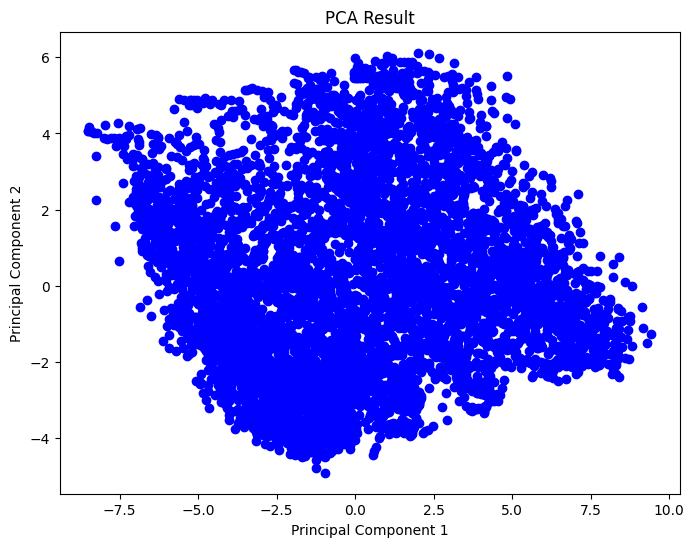

In [15]:
from sklearn.decomposition import PCA

training_feature_df = scaler.fit(training_feature_df).transform(training_feature_df)

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(training_feature_df)

# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='blue', marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [16]:
# LOAD PARAMETERS
SYNTHETIC_PARAMS = {
    'unit': 'VG5',
    'test_set': '01',
    'anomaly_type': 'a',
    'set_type':'test_s01'
}

rds_u5_buffer = RawDataset(dataset_root, "VG5", load_synthetic=False, load_training=False)

test_syn_df = preprocess_hydraulic_synthetic_dataset(rds_train=rds_u5_buffer,
                                                     training_df=rds_u5_turb_ss_volt, 
                                                     unit=SYNTHETIC_PARAMS["unit"],
                                                     number = SYNTHETIC_PARAMS["test_set"],
                                                     Type = SYNTHETIC_PARAMS["anomaly_type"],
                                                     scaler=scaler)

In [17]:
test_syn_df = convert_to_tsfresh_format(test_syn_df, window_size=window_size)

In [18]:
test_syn_feature_df = extract_features(test_syn_df, column_id='id', column_sort='time',
                                       #default_fc_parameters=extraction_settings,
                                       kind_to_fc_parameters=kind_to_fc_parameters,
                                       # we impute = remove all NaN features automatically
                                       impute_function=impute)

Feature Extraction: 100%|██████████| 20/20 [00:13<00:00,  1.48it/s]


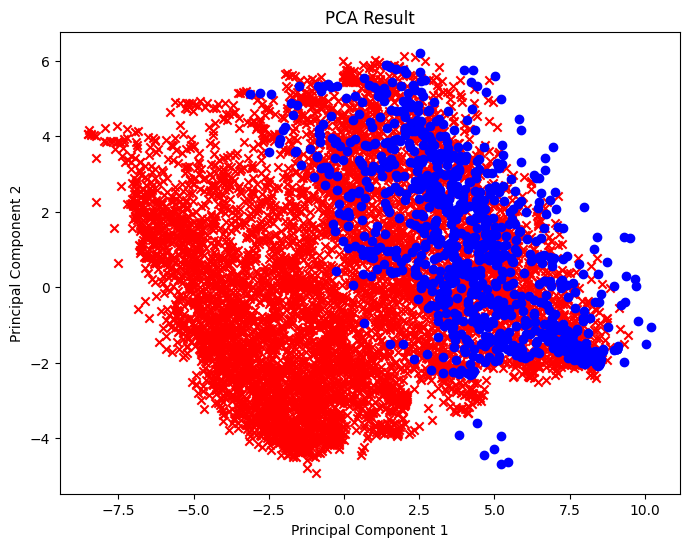

In [19]:
test_syn_feature_df = scaler.transform(test_syn_feature_df)

pca_result_test = pca.transform(test_syn_feature_df)

# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='red', marker='x')
plt.scatter(pca_result_test[:, 0], pca_result_test[:, 1], c="blue", marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [20]:
t_sne = TSNE(n_components=2)

t_sne_result = t_sne.fit_transform(training_feature_df)

In [21]:
t_sne_test_result = t_sne.fit_transform(test_syn_feature_df)

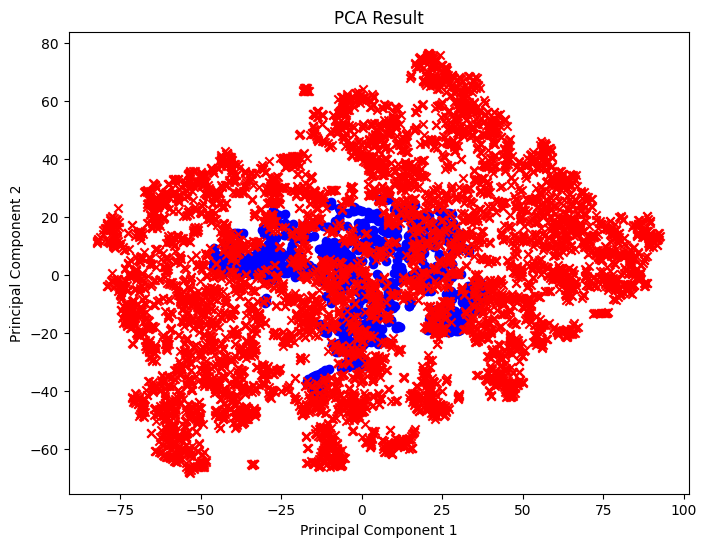

In [22]:
# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(t_sne_test_result[:, 0], t_sne_test_result[:, 1], c='blue', marker='o')
plt.scatter(t_sne_result[:, 0], t_sne_result[:, 1], c='red', marker='x')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()